# Instructions on using this Calculator

## Introduction

This Jupyter Notebook can be used to calculate the accuracy of your Model Output. It works as follows. Please ensure the following are loaded into your environment before running this notebook: 

1) All 5 clipped CDL tif images, named 2019_cdl_clipped.tif, 2020_cdl_clipped.tif, 2021_cdl_clipped.tif, 2022_cdl_clipped.tif and 2023_cdl_clipped.tif
2) The vector image output from your model, named model_output.tif

In addition, please make sure your notebook has at least 24 cores at 8GB each, otherwise some of these accuracy calculations will take a very long time.

This code has 4 steps to it. Steps 1-3 on

## Step 1 - CDL Image Labeling

This section of code will process each CDL filed into a data frame. The data frame will contain the x/y coordinate for each pixel, the pixel's grayscale value, crop type (based on a crop mapping dictionary) and assigned field group (based on groupings of same-color pixels). A majority filter is applied to the dataframe, which is used to remove noise from an image or data. It replaces each pixel's value with the majority of the pixel values in its neighborhood (3x3 square block in this case) of all other pixels in the neighborhood are a uniform color.

Note - You only need to run this step one time in order to prep your CDL dataframes for step 2.

In [1]:
import rasterio
import numpy as np
import pandas as pd
from rasterio.windows import Window
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import label
from skimage.transform import resize
from PIL import Image
from scipy.ndimage import generic_filter
import os
from matplotlib.colors import ListedColormap

In [2]:
# Load Reference CDL Images
reference_tif_2019 = "2019cdl_matched2sentinel.tif"
#reference_tif_2020 = "2020cdl_matched2sentinel.tif"
#reference_tif_2021 = "2021cdl_matched2sentinel.tif"
#reference_tif_2022 = "2022cdl_matched2sentinel.tif"
#reference_tif_2023 = "2023cdl_matched2sentinel.tif"

In [3]:
#3, 25, 56, 57, 76,219, 221, 246

In [4]:
# Define crop mapping (grayscale values to crop labels)
CROP_TYPE_MAP = {
    0: "Out of Shapefile Bounds",
    1: "Corn", 
    4: "Sorghum", 
    5: "Soybeans", 
    6: "Sunflower", 
    12: "Sweet Corn", 
    13: "Pop or Orn Corn", 
    14: "Mint", 
    21: "Barley", 
    23: "Spring Wheat", 
    24: "Winter Wheat", 
    26: "Dbl Crop WinWht/Soybeans", 
    27: "Rye",
    28: "Oats",
    29: "Millet",
    30: "Speltz",
    31: "Canola",
    36: "Alfalfa",
    37: "Other Hay/Non Alfalfa",
    39: "Buckwheat",
    41: "Sugarbeets",
    42: "Dry Beans",
    43: "Potatoes",
    44: "Other Crops",
    47: "Misc Vegs & Fruits",
    48: "Watermelons",
    49: "Onions",
    50: "Cucumbers",
    53: "Peas",
    54: "Tomatoes",
    58: "Clover/Wildflowers",
    59: "Sod/Grass Seed",
    60: "Switchgrass",
    61: "Fallow/Idle Cropland",
    66: "Cherries",
    67: "Peaches",
    68: "Apples",
    69: "Grapes",
    70: "Christmas Trees",
    71: "Other Tree Crops",
    77: "Pears",
    92: "Aquaculture",
    111: "Open Water",
    121: "Developed/Open Space",
    122: "Developed/Low Intensity",
    123: "Developed/Med Intensity ",
    124: "Developed/High Intensity",
    131: "Barren",
    141: "Deciduous Forest",
    142: "Evergreen Forest",
    143: "Mixed Forest",
    152: "Shrubland",
    176: "Grassland/Pasture",
    190: "Woody Wetlands",
    195: "Herbaceous Wetlands",
    205: "Triticale",
    206: "Carrots",
    207: "Asparagus",
    209: "Cantaloupes",
    216: "Peppers",
    220: "Plums",
    222: "Squash",
    225: "Dbl Crop WinWht/Corn",
    228: "Dbl Crop Triticale/Corn",
    229: "Pumpkins",
    236: "Dbl Crop WinWht/Sorghum",
    240: "Dbl Crop Soybeans/Oats",
    242: "Blueberries",
    243: "Cabbage",
    245: "Celery",
    247: "Turnips"
}

In [5]:
#Create Majority Filter that will be used to filter out noise
def conditional_majority_filter(image, size=3):
    """Applies a majority filter only if the center pixel is the only outlier.
    
    Args:
        image (numpy array): The input image.
        size (int): The size of the filtering window (default is 3x3).
        
    Returns:
        numpy array: The filtered image.
    """
    def majority_if_outlier(values):
        center_pixel = values[len(values) // 2]  # Center pixel in the window
        surrounding_pixels = np.delete(values, len(values) // 2)  # Exclude center pixel
        
        # Check if all surrounding pixels are the same
        if np.all(surrounding_pixels == surrounding_pixels[0]) and center_pixel != surrounding_pixels[0]:
            return surrounding_pixels[0]  # Replace with majority (surrounding value)
        else:
            return center_pixel  # Keep original value

    return generic_filter(image, majority_if_outlier, size=(size, size))

In [6]:
#Uses the CROP_TYPE_MAP to apply crop labels to each pixel based on their grayscale value

def label_crops (reference_tif):
# Open the TIFF image
    with rasterio.open(reference_tif) as src:
        # Read the image data (first band)
        band = src.read(1)  # Read the first band (single-band image)

        # Get the image dimensions
        height, width = band.shape

    # Generate x and y coordinate arrays
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten the arrays and create a DataFrame
    df = pd.DataFrame({
        'x': x_coords.flatten(),
        'y': y_coords.flatten(),
        'grayscale_value': band.flatten()
    })
    
    # Function to map grayscale values to crop types
    def map_crop(grayscale_value):
        return CROP_TYPE_MAP.get(grayscale_value, "Unknown")  # Default to "Unknown" if not found

    # Apply the mapping function to create the 'crop_type' column
    df['crop_type'] = df['grayscale_value'].apply(map_crop)

    # Display the first few rows of the DataFrame
    return df

In [7]:
# Function to group pixels together based on color and assign field labels (with majority filter). Adds field_id column onto existing dataframe 
def label_fields_with_filter(df: pd.DataFrame, reference_tif):
    # Open the TIFF file
    with rasterio.open(reference_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    # Apply a majority filter to remove noise & prevent small pixel errors (optional step)
    ref_image = conditional_majority_filter(ref_image, size=3)    

    height, width = ref_image.shape

    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Define 4-connectivity structure (no diagonals)
    structure_4 = np.array([[0, 1, 0],
                            [1, 1, 1],
                            [0, 1, 0]], dtype=bool)

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category using 4-connectivity
        labeled_regions = label(mask, structure=structure_4)[0]

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

In [8]:
#Process CDL tifs with filter (you can comment out any CDLs you are not using)
field_label_df_2019_with_filter, field_labels_2019_with_filter = label_fields_with_filter((label_crops(reference_tif_2019)), reference_tif_2019)
#field_label_df_2020_with_filter, field_labels_2020_with_filter = label_fields_with_filter((label_crops(reference_tif_2020)), reference_tif_2020)
#field_label_df_2021_with_filter, field_labels_2021_with_filter = label_fields_with_filter((label_crops(reference_tif_2021)), reference_tif_2021)
#field_label_df_2022_with_filter, field_labels_2022_with_filter = label_fields_with_filter((label_crops(reference_tif_2022)), reference_tif_2022)
#field_label_df_2023_with_filter, field_labels_2023_with_filter = label_fields_with_filter((label_crops(reference_tif_2023)), reference_tif_2023)

In [ ]:
######## EVERYTHING AFTER THIS POINT IN STEP 1 IS USED TO PERFORM RESEARCH OR CREATE VISUALIZATIONS FOR THE REPORT. YOU CAN SKIP TO STEP 2 ######## 

In [ ]:
#Saves file references in list
tif_files = [
    reference_tif_2019,
    reference_tif_2020,
    reference_tif_2021,
    reference_tif_2022,
    reference_tif_2023
]

In [ ]:
#The following grayscsale values exist in the tif images, but do not have a crop label in the metadata: 3, 25, 56, 57, 76,219, 221, 246

In [ ]:
#Code look at how many differet crop labels exist in 1 field
print("Unique field IDs assigned:", np.unique(field_labels_2019_with_filter))
print(field_label_df_2019_with_filter.groupby("field_id")["crop_type"].nunique().sort_values(ascending=False))

In [ ]:
#Print number of unique fields for a year
num_unique_fields = field_label_df_2019_with_filter["field_id"].nunique()
print(f"Number of unique fields: {num_unique_fields}")

In [ ]:
# Show visualization of a specific field

# Select the field ID you want to highlight
target_field_id = 68258  # Change this to the field ID you want to highlight

# Create a binary mask: White (255) for the target field, Black (0) for others
highlight_mask = np.zeros_like(field_labels_2019_with_filter, dtype=np.uint8)
highlight_mask[field_labels_2019_with_filter == target_field_id] = 255  # Set the target field to white

# Display the mask
plt.figure(figsize=(10, 10))
plt.imshow(highlight_mask, cmap='gray')  # Black & White representation
plt.title(f"Highlighted Field ID: {target_field_id}")
plt.axis('off')  # Hide axes for a clean image
plt.show()

In [ ]:
#Show all fields for a specific grayscale value

# Specify the grayscale value you want to display (change it to the value you're interested in)
with rasterio.open(reference_tif_2021) as src:
    ref_image2019 = src.read(1)

test_value = 0  # Replace with your desired grayscale value
print(f"Displaying mask for grayscale value: {test_value}")

# Create a binary mask where all pixels matching the test_value are white (1), others are black (0)
test_mask = (ref_image2019 == test_value)

# Display the mask using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(test_mask, cmap="gray")
plt.title(f"Fields for grayscale value {test_value}")
plt.axis("off")  # Optional: Hide axis for a cleaner map
plt.show()

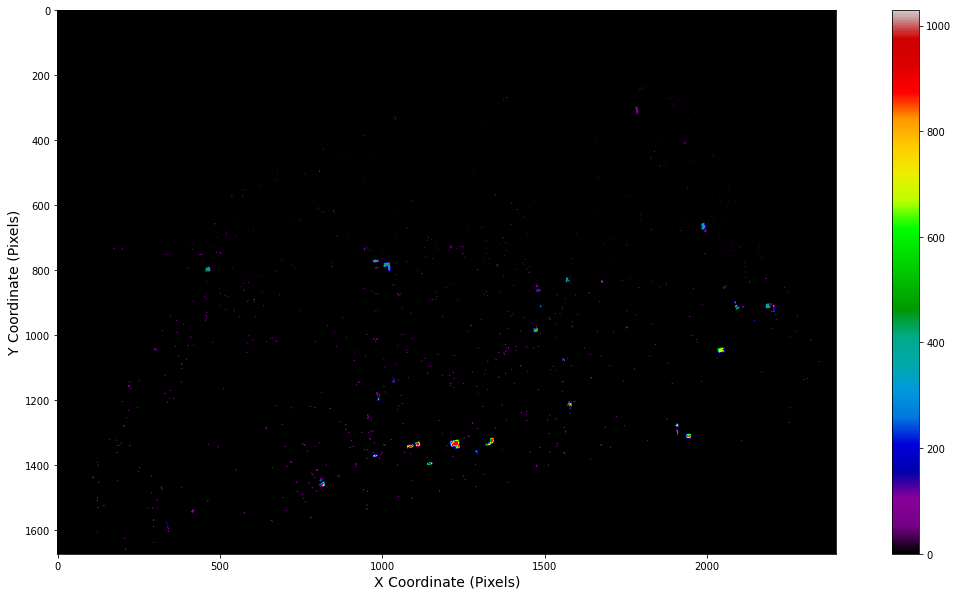

In [33]:
#Show all fields for a specific grayscale value with colored field labels
labeled_test_mask = label(test_mask)
# Display the mask using matplotlib
plt.figure(figsize=(20, 10))
plt.imshow(labeled_test_mask, cmap="nipy_spectral")  # Use a colorful colormap
#plt.title(f"Fields for grayscale value {test_value}")
plt.colorbar()
plt.xlabel("X Coordinate (Pixels)", fontsize=14)
plt.ylabel("Y Coordinate (Pixels)", fontsize=14)
plt.show()

In [40]:
# Get the top 10 field_ids with the most records
top_10_field_ids = field_labels_2019["field_id"].value_counts().head(10)

print("Top 10 field_ids with the most records:")
print(top_10_field_ids)

Top 10 field_ids with the most records:
0       1608690
2552       7101
2288       5847
518        4565
6940       4507
5425       4351
956        3849
689        3844
4461       3713
2406       3573
Name: field_id, dtype: int64


In [8]:
#This cell is run to print all unique grayscale values, so we can make sure our crop dictionary is inclusive of everytihng
# Set to store all unique grayscale values across files
all_unique_values = set()

# Loop through the specified TIFF files and prints grayscale values
for tif_path in tif_files:
    with rasterio.open(tif_path) as src:
        band = src.read(1)  # Read the single-band image
        unique_values = np.unique(band)  # Get unique values in this image
        all_unique_values.update(unique_values)  # Add to global set
    
    print(f"Unique grayscale values in {tif_path}: {unique_values}")

Unique grayscale values in 2019_cdl_clipped.tif: [  0   1   4   5  12  13  14  21  24  25  27  28  30  36  37  41  42  43
  44  49  50  53  54  56  57  58  59  61  66  68  70 111 121 122 123 124
 131 141 142 143 152 176 190 195 205 206 219 222 225 229 243]
Unique grayscale values in 2020_cdl_clipped.tif: [  0   1   3   4   5   6  12  13  14  21  22  24  26  27  28  29  30  36
  37  39  41  42  43  44  47  48  49  50  53  54  56  58  59  60  61  66
  68  70  71  76 111 121 122 123 124 131 141 142 143 152 176 190 195 205
 206 222 225 229 242 243 246]
Unique grayscale values in 2021_cdl_clipped.tif: [  0   1   4   5   6  12  13  14  21  24  26  27  28  29  30  31  36  37
  39  41  42  43  44  47  49  50  53  54  56  57  58  59  61  66  68  69
  70  71  76  77  92 111 121 122 123 124 131 141 142 143 152 176 190 195
 205 206 207 216 219 221 222 225 228 229 242 243 245 246]
Unique grayscale values in 2022_cdl_clipped.tif: [  0   1   4   5   6  12  14  21  23  24  26  27  28  29  30  36  37  

## Step 2 - Model Output Image Processing

This code will define functions that will process a grayscale model output tif into a data frame. The data frame will contain the x/y coordinate for each pixel, the pixel's grayscale value and assigned field group (based on groupings of same-color pixels).

In [9]:
#Define function to process model output
def label_satelite_pixels(model_output_tif):
    with rasterio.open(model_output_tif) as src:
        band = src.read(1).astype(np.uint8)  # Read and convert to uint8 if needed

        # Get original dimensions
        height, width = band.shape

    # Generate x and y coordinate arrays
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten and create DataFrame
    df = pd.DataFrame({
        'x': x_coords.flatten(),
        'y': y_coords.flatten(),
        'grayscale_value': band.flatten()
    })

    return df

In [10]:
# Function to group pixels together based on color and assign field labels (with no majority filter). Adds field_id column onto existing dataframe 
def process_model_output(df: pd.DataFrame, reference_tif):
    # Open the TIFF file
    with rasterio.open(reference_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Define 4-connectivity structure (no diagonals)
    structure_4 = np.array([[0, 1, 0],
                            [1, 1, 1],
                            [0, 1, 0]], dtype=bool)

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category using 4-connectivity
        labeled_regions = label(mask, structure=structure_4)[0]

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

## Step 3 - Create Accuracy Calculators

This code will create the IoU, field noise and pixel-level accuracy calculators. 

In [11]:
#this creates an array of non-crop grayscale values that we want to exclude from the calculation
exclude_grayscale_values = [0, 3, 25, 56, 57, 61, 76, 92, 111, 121, 123, 124, 131, 141, 142, 143, 152, 176, 190, 195, 219, 221, 246]

In [12]:
def compute_field_noise(df_model_output, df_truth, exclude_grayscale_values, bin_size=10): 
    # Print number of records in each DataFrame
    print(f"Records in df_model_output: {len(df_model_output)}")
    print(f"Records in df_truth: {len(df_truth)}")

    # Merge both dataframes on pixel coordinates ("x", "y")
    df_merged = df_model_output.merge(df_truth, on=["x", "y"], suffixes=("_labeled", "_truth"))

    # Determine the majority truth field per labeled field
    majority_truth = df_merged.groupby("field_id_labeled")["field_id_truth"].agg(lambda x: x.value_counts().idxmax()).reset_index()
    majority_truth.rename(columns={"field_id_truth": "majority_truth"}, inplace=True)

    # Merge majority field back into df_merged
    df_merged = df_merged.merge(majority_truth, on="field_id_labeled")

    # Get the majority grayscale value for each field_id in df_truth
    majority_grayscale = df_truth.groupby("field_id")["grayscale_value"].agg(lambda x: x.value_counts().idxmax()).reset_index()
    majority_grayscale.rename(columns={"grayscale_value": "majority_grayscale"}, inplace=True)

    # Merge this majority grayscale value onto df_merged via the majority_truth field
    df_merged = df_merged.merge(majority_grayscale, left_on="majority_truth", right_on="field_id", suffixes=("", "_gray"))

    # Now exclude only fields whose majority grayscale is in the exclusion list
    excluded_fields_by_grayscale = df_merged[df_merged["majority_grayscale"].isin(exclude_grayscale_values)]["field_id_labeled"].unique()

    # Count excluded fields due to majority grayscale value in exclusion list
    num_excluded_fields_by_grayscale = len(excluded_fields_by_grayscale)

    # Calculate field sizes (pixel count per field)
    field_sizes = df_model_output.groupby("field_id").size().reset_index(name="field_size")

    # Find 1-pixel fields
    one_pixel_fields = field_sizes[field_sizes["field_size"] == 1]["field_id"].unique()

    # Count excluded 1-pixel fields
    num_excluded_one_pixel_fields = len(one_pixel_fields)

    # Exclude both 1-pixel fields and those from grayscale exclusion
    excluded_fields = set(excluded_fields_by_grayscale) | set(one_pixel_fields)
    df_merged = df_merged[~df_merged["field_id_labeled"].isin(excluded_fields)]

    # Compute noise: pixels that do not match the majority field_id_truth
    df_merged["is_noise"] = df_merged["field_id_truth"] != df_merged["majority_truth"]

    # Compute noise score (percentage of noisy pixels per field)
    noise_scores = df_merged.groupby("field_id_labeled")["is_noise"].mean().reset_index()
    noise_scores.rename(columns={"field_id_labeled": "field_id", "is_noise": "noise_score"}, inplace=True)

    # Merge noise scores with field sizes (after filtering)
    df_noise = noise_scores.merge(field_sizes, on="field_id")

    # Assign bin labels (e.g., "1-10", "11-20", etc.)
    df_noise["field_size_bin"] = (df_noise["field_size"] // bin_size) * bin_size
    df_noise["field_size_bin"] = df_noise["field_size_bin"].astype(str) + "-" + (df_noise["field_size_bin"] + bin_size).astype(str)

    # Compute average noise score per bin and count fields in each bin
    df_avg_noise = df_noise.groupby("field_size_bin").agg(
        avg_noise_score=("noise_score", "mean"),
        field_count=("field_id", "count")
    ).reset_index()

    # Rename for clarity
    df_avg_noise.rename(columns={"field_size_bin": "field_size"}, inplace=True)

    # Sort by lower bound of field_size bin
    df_avg_noise["sort_key"] = df_avg_noise["field_size"].str.extract(r"^(\d+)", expand=False).astype(int)
    df_avg_noise = df_avg_noise.sort_values(by="sort_key").drop(columns="sort_key")

    # Print excluded pixel info
    print(f"Excluded {num_excluded_one_pixel_fields} fields with only 1 pixel.")
    print(f"Excluded {num_excluded_fields_by_grayscale} fields due to majority grayscale value being in the excluded list.")
    
    # Calculate total average noise across all fields
    total_avg_noise = df_noise["noise_score"].mean()
    print(f"Total average field noise across all fields: {total_avg_noise:.4f}")

    return df_avg_noise

In [13]:
def compute_pixel_level_accuracy(df_model_output, df_truth, exclude_values):
    print(f"Records in df_model_output: {len(df_model_output)}")
    print(f"Records in df_truth: {len(df_truth)}")

    # Rename to avoid column collisions
    df_model_output = df_model_output.rename(columns={"field_id": "field_id_labeled"})
    df_truth = df_truth.rename(columns={"field_id": "field_id_truth"})

    # Filter out excluded grayscale values
    removed_truth = df_truth[df_truth["grayscale_value"].isin(exclude_values)]
    df_truth = df_truth[~df_truth["grayscale_value"].isin(exclude_values)]
    excluded_coords = set(zip(removed_truth["x"], removed_truth["y"]))
    df_model_output = df_model_output[~df_model_output.set_index(["x", "y"]).index.isin(excluded_coords)]

    print(f"Removed {len(removed_truth)} non-crop grayscale pixels from df_truth and {len(excluded_coords)} corresponding pixels from df_model_output.")

    # Merge on coordinates
    df_merged = df_model_output.merge(df_truth, on=["x", "y"], how="inner")

    # Step 1: Count pixels in each truth field
    field_sizes = df_truth["field_id_truth"].value_counts()
    df_merged["expected_field_size"] = df_merged["field_id_truth"].map(field_sizes)

    # Step 2: Count pixels that share the same labeled + truth field pair
    match_counts = df_merged.groupby(["field_id_labeled", "field_id_truth"]).size().reset_index(name="match_count")

    # Merge match counts back into df_merged
    df_merged = df_merged.merge(match_counts, on=["field_id_labeled", "field_id_truth"], how="left")

    # Step 3: Compute pixel-level accuracy
    # Subtract 1 to exclude the pixel itself
    df_merged["pixel_accuracy"] = (df_merged["match_count"] - 1) / (df_merged["expected_field_size"] - 1)

    # Step 4: Final accuracy
    overall_accuracy = df_merged["pixel_accuracy"].mean()

    print(f"Overall Pixel-Group Inclusion: {overall_accuracy:.2%}")

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def calculate_iou(truth_tif_path, model_output_tif_path, exclude_values=[]):
    # Load raster images
    with rasterio.open(truth_tif_path) as src1:
        gt_raw = src1.read(1)

    with rasterio.open(model_output_tif_path) as src2:
        pred_raw = src2.read(1)

    # Create binary ground truth and prediction masks
    gt = (gt_raw > 0).astype(int)
    pred = (pred_raw > 0).astype(int)

    # Create 2D boolean mask for valid pixels (exclude specified grayscale values)
    mask = ~np.isin(gt_raw, exclude_values)

    # Apply mask to compute IoU (flattened)
    gt_masked = gt[mask]
    pred_masked = pred[mask]

    # Calculate intersection and union
    intersection = np.logical_and(gt_masked, pred_masked).sum()
    union = np.logical_or(gt_masked, pred_masked).sum()

    if union == 0:
        print("Warning: Union is zero, IoU is undefined.")
        return None

    iou = intersection / union

    # Create visualization image (still 2D)
    visual = np.zeros_like(gt_raw, dtype=np.uint8)
    visual[np.logical_and(gt == 1, pred == 1) & mask] = 3  # Intersection → Purple
    visual[np.logical_and(gt == 1, pred == 0) & mask] = 1  # GT only → Red
    visual[np.logical_and(gt == 0, pred == 1) & mask] = 2  # Prediction only → Blue

    # Custom colormap
    cmap = ListedColormap([
        'black',    # 0 → background
        'red',      # 1 → ground truth only
        'blue',     # 2 → prediction only
        'purple'    # 3 → intersection
    ])

    # Plot the visualization
    plt.figure(figsize=(10, 10))
    im = plt.imshow(visual, cmap=cmap)
    plt.title(f"IOU Visualization\nIoU Score = {iou:.4f}", fontsize=14)
    plt.axis('off')

    # Add custom legend
    legend_patches = [
        Patch(color='black', label='Non-crop Fields'),
        Patch(color='red', label='Ground Truth Only'),
        Patch(color='blue', label='Prediction Only'),
        Patch(color='purple', label='Intersection')
    ]
    plt.legend(handles=legend_patches, loc='lower right', fontsize=10, frameon=True)

    plt.show()

    print(f"IoU Score: {iou:.4f}")
    return iou

## Step 4 - Perform Accuracy Calculation

This section of code performs the accuracy calculation. The model_output and df_truth variables in the cell below should be changed by the user to reference your model output image and associated CDL image that you want to compare it to.

In [15]:
# First, process your model output
model_output = "fullseason3_cropland_mask.tif" #Replace monica.tif with your model output tif file
df_truth = field_label_df_2019_with_filter #Replace with cdl year you want to compare to
df_model_output, field_labels = process_model_output((label_satelite_pixels(model_output)), model_output)

Calculator 1 - Field Noise -  For each field in the model output, this calculation will identify how many pixels were expected to be in a different field based on the CDL image. The majority field is considered the "correct" field. For instance, if a field has 10 pixels, where 3 of them belong to the same field per the CDL file, and the other 7 all belong to 7 different fields per the CDL file, then the 3 pixels would be considered the "correct" field and the noise score would be 70%.

A lower noise score is better (less noise).

Parameters: 
* df_model_output = Processed model output
* df_truth = Processed CDL file for the corresponding year
* exclude_grayscale_values = List of non-crop fields created earlier
* bin_size = Groups field sizes together to calculate average noise (defaults to 10)

In [16]:
compute_field_noise(df_model_output, df_truth, exclude_grayscale_values, bin_size = 1000)

Records in df_model_output: 31148516
Records in df_truth: 31148516
Excluded 0 fields with only 1 pixel.
Excluded 21 fields due to majority grayscale value being in the excluded list.
Total average field noise across all fields: 0.5947


,field_size,avg_noise_score,field_count
0,0-1000,0.213115,1
21,3000-4000,0.351412,68
30,4000-5000,0.472806,47
35,5000-6000,0.418246,52
40,6000-7000,0.604708,35
45,7000-8000,0.558750,30
47,8000-9000,0.579486,30
49,9000-10000,0.548166,28
1,10000-11000,0.635415,28
2,11000-12000,0.597707,21


Calculator 2 - Pixel Group -  For each pixel in the model output, this calculation will identify how many expected pixels from it's field were correctly grouped by the model.

A higher grouping score is better (less noise).

Parameters: 
* df_model_output = Processed model output
* df_truth = Processed CDL file for the corresponding year
* exclude_grayscale_values = List of non-crop fields created earlier

In [17]:
compute_pixel_level_accuracy(df_model_output, df_truth, exclude_grayscale_values)

Records in df_model_output: 31148516
Records in df_truth: 31148516
Removed 14629271 non-crop grayscale pixels from df_truth and 14629271 corresponding pixels from df_model_output.
Overall Pixel-Group Inclusion: 83.46%


Calculator 3 - IoU - This creates a mask of all crop fields identified by the model and compares it to the CDL image to determine how well the model was able to identify crop fields. 

A higher IoU score is better (more cropland identified)

Parameters: 
* df_model_output = Processed model output
* df_truth = Processed CDL file for the corresponding year
* exclude_grayscale_values = List of non-crop fields created earlier

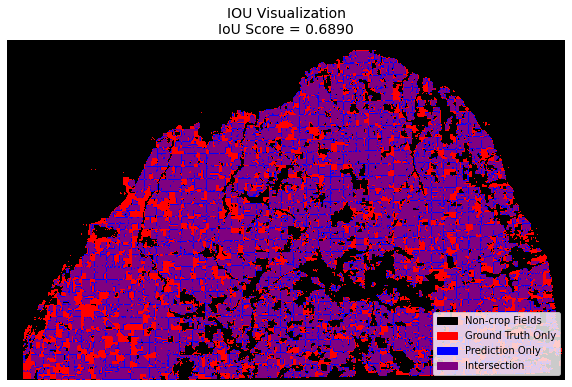

IoU Score: 0.6890


0.6890087894452803

In [22]:
calculate_iou(reference_tif_2019, model_output, exclude_grayscale_values)